In [1]:
# ============================================
# Credit Card Fraud Detection
# Algorithm: Decision Tree
# ============================================

# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef
)

from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")

In [2]:
# ============================================
# 2. Load Dataset
# ============================================

df = pd.read_csv("creditcard.csv")

print("\n===========================================")
print("DATASET INFORMATION")
print("===========================================")
print("Original Dataset Shape:", df.shape)


DATASET INFORMATION
Original Dataset Shape: (284807, 31)


In [3]:
# ============================================
# 3. Handle Duplicate Values
# ============================================

duplicate_count = df.duplicated().sum()

print("\nDuplicate Rows Found:", duplicate_count)

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)


Duplicate Rows Found: 1081
Dataset Shape After Removing Duplicates: (283726, 31)


In [4]:
# ============================================
# 4. Dataset Info
# ============================================

print("\n===========================================")
print("DATASET STRUCTURE")
print("===========================================")
df.info()


DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 


CLASS DISTRIBUTION
Class
0    283253
1       473
Name: count, dtype: int64


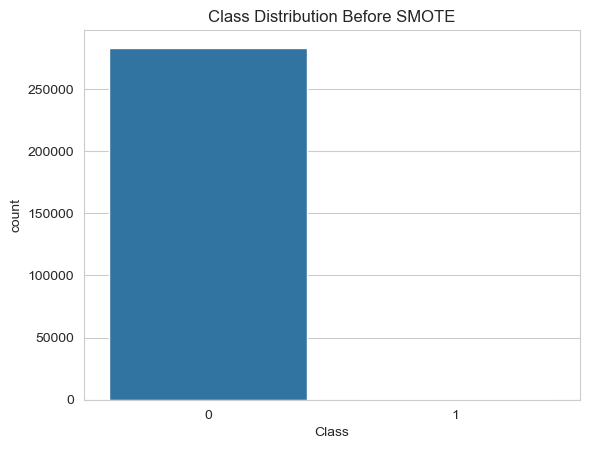

In [5]:
# ============================================
# 5. Class Distribution
# ============================================

print("\n===========================================")
print("CLASS DISTRIBUTION")
print("===========================================")
print(df["Class"].value_counts())

sns.countplot(x="Class", data=df)
plt.title("Class Distribution Before SMOTE")
plt.show()

In [6]:
# ============================================
# 6. Missing Values
# ============================================

print("\n===========================================")
print("MISSING VALUES")
print("===========================================")
print(df.isnull().sum())


MISSING VALUES
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
# ============================================
# 7. Feature Scaling
# ============================================

scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = scaler.fit_transform(df[["Time"]])

In [8]:
# ============================================
# 8. Features and Labels
# ============================================

X = df.drop("Class", axis=1)
y = df["Class"]

In [9]:
# ============================================
# 9. Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n===========================================")
print("DATA SPLIT")
print("===========================================")
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)


DATA SPLIT
Training Set: (226980, 30)
Testing Set : (56746, 30)


In [10]:
# ============================================
# 10. SMOTE
# ============================================

print("\n===========================================")
print("CLASS BALANCING USING SMOTE")
print("===========================================")

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\nNew Training Set Size:", X_train_smote.shape[0])


CLASS BALANCING USING SMOTE
Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64

New Training Set Size: 453204


In [11]:
# ============================================
# 11. Hyperparameter Tuning
# ============================================

print("\n===========================================")
print("HYPERPARAMETER TUNING")
print("===========================================")

param_grid = {
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_search.best_params_)

model = grid_search.best_estimator_
model.fit(X_train_smote, y_train_smote)


HYPERPARAMETER TUNING
Best Parameters: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2}


,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
# ============================================
# 12. Prediction
# ============================================

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [13]:
# ============================================
# 13. Model Evaluation
# ============================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print("\n===========================================")
print("MODEL PERFORMANCE")
print("===========================================")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")
print(f"MCC               : {mcc:.4f}")

print("\n===========================================")
print("CLASSIFICATION REPORT")
print("===========================================")
print(classification_report(y_test, y_pred))


MODEL PERFORMANCE
Accuracy          : 0.9786
Precision         : 0.0598
Recall            : 0.8000
F1 Score          : 0.1113
Balanced Accuracy : 0.8895
MCC               : 0.2152

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.80      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.89      0.55     56746
weighted avg       1.00      0.98      0.99     56746




CONFUSION MATRIX DETAILS
True Negatives : 55456
False Positives: 1195
False Negatives: 19
True Positives : 76
Specificity    : 0.9789


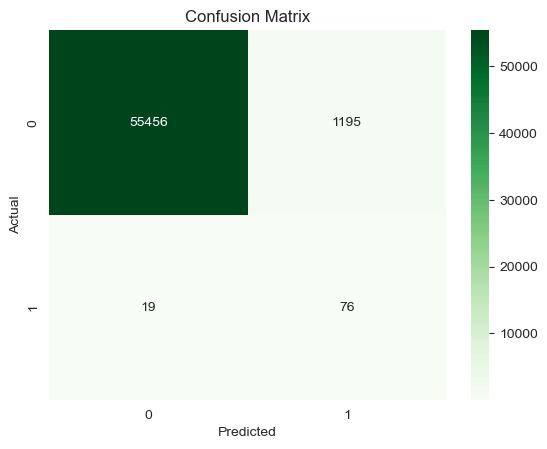

In [14]:
# ============================================
# 14. Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)

print("\n===========================================")
print("CONFUSION MATRIX DETAILS")
print("===========================================")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")
print(f"Specificity    : {specificity:.4f}")

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


ROC ANALYSIS
ROC AUC Score: 0.8708


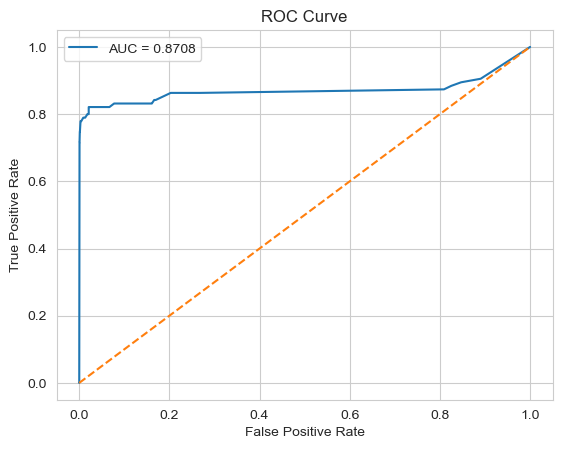

In [15]:
# ============================================
# 15. ROC Curve
# ============================================

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n===========================================")
print("ROC ANALYSIS")
print("===========================================")
print(f"ROC AUC Score: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


PRECISION-RECALL ANALYSIS
Average Precision Score: 0.4729


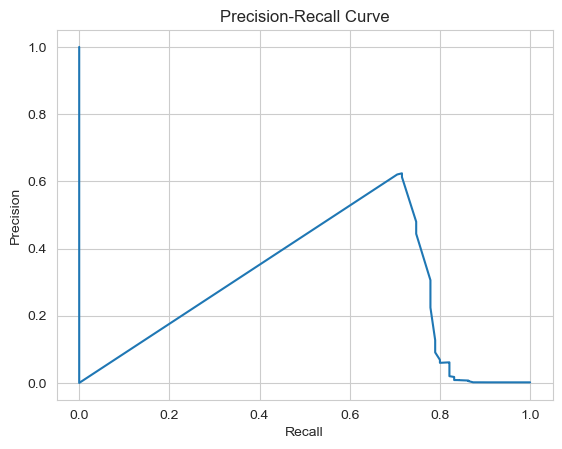

In [16]:
# ============================================
# 16. Precision-Recall Curve
# ============================================

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

print("\n===========================================")
print("PRECISION-RECALL ANALYSIS")
print("===========================================")
print(f"Average Precision Score: {avg_precision:.4f}")

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [17]:
# ============================================
# 17. Cross Validation
# ============================================

cv_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='f1')

print("\n===========================================")
print("CROSS VALIDATION")
print("===========================================")
print("F1 Scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())


CROSS VALIDATION
F1 Scores: [0.98189348 0.98214168 0.98079473 0.98167894 0.98316677]
Mean F1 Score: 0.9819351183536937


In [18]:
# ============================================
# 18. Overfitting Check
# ============================================

train_pred = model.predict(X_train_smote)

print("\n===========================================")
print("OVERFITTING CHECK")
print("===========================================")
print("Training Accuracy:", accuracy_score(y_train_smote, train_pred))
print("Testing Accuracy :", accuracy_score(y_test, y_pred))


OVERFITTING CHECK
Training Accuracy: 0.982489121896541
Testing Accuracy : 0.978606421597998



FEATURE IMPORTANCE
V14       0.799904
V4        0.060553
V12       0.017684
V13       0.015154
V3        0.014948
V10       0.014072
V9        0.012118
Amount    0.008938
V8        0.007996
V7        0.006461
dtype: float64


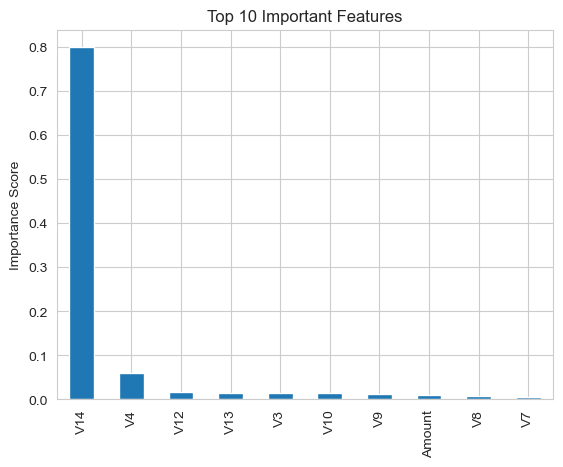

In [19]:
# ============================================
# 19. Feature Importance
# ============================================

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

print("\n===========================================")
print("FEATURE IMPORTANCE")
print("===========================================")
print(top_features)

top_features.plot(kind='bar')
plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.show()

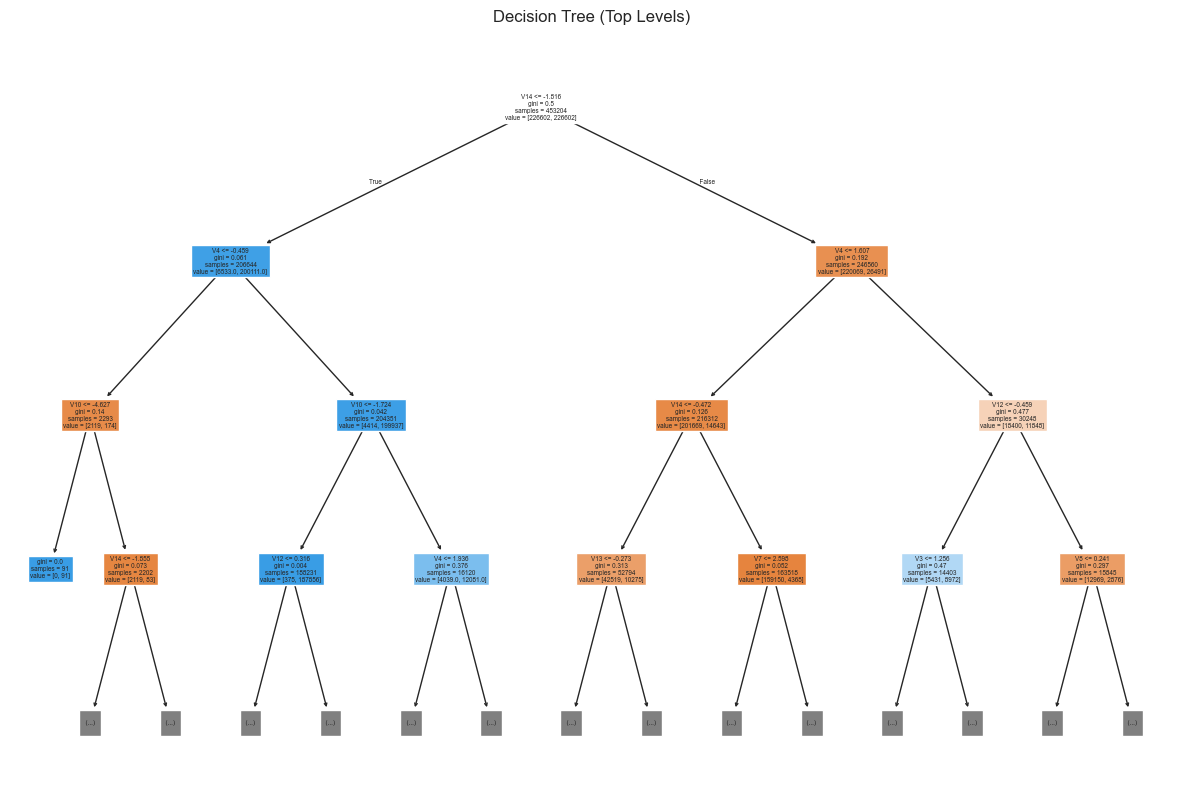

In [20]:
# ============================================
# 20. Decision Tree Visualization
# ============================================

plt.figure(figsize=(15, 10))
plot_tree(model, max_depth=3, filled=True, feature_names=X.columns)
plt.title("Decision Tree (Top Levels)")
plt.show()